# Quantium Virtual Internship - Retail Strategy and Analytics - Task 1

## Load required libraries and datasets

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import re

In [2]:
customerData=pd.read_csv("QVI_purchase_behaviour.csv")

In [3]:
transactionData = pd.read_excel('QVI_transaction_data.xlsx', engine='openpyxl')

In [4]:
transactionData.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [5]:
customerData.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


# Exploratory data analysis

### Examining transaction data

In [6]:
transactionData.dtypes

DATE                int64
STORE_NBR           int64
LYLTY_CARD_NBR      int64
TXN_ID              int64
PROD_NBR            int64
PROD_NAME             str
PROD_QTY            int64
TOT_SALES         float64
dtype: object

In [7]:
#We can see that the date column is in an integer format. Let's change this to a date format.
transactionData['DATE'] = pd.to_datetime(transactionData['DATE'], origin='1899-12-30', unit='D')

In [8]:
unique_prod=transactionData['PROD_NAME'].unique()

In [9]:
print(unique_prod)

<StringArray>
[  'Natural Chip        Compny SeaSalt175g',
                 'CCs Nacho Cheese    175g',
   'Smiths Crinkle Cut  Chips Chicken 170g',
   'Smiths Chip Thinly  S/Cream&Onion 175g',
 'Kettle Tortilla ChpsHny&Jlpno Chili 150g',
 'Old El Paso Salsa   Dip Tomato Mild 300g',
 'Smiths Crinkle Chips Salt & Vinegar 330g',
    'Grain Waves         Sweet Chilli 210g',
  'Doritos Corn Chip Mexican Jalapeno 150g',
    'Grain Waves Sour    Cream&Chives 210G',
 ...
         'Doritos Cheese      Supreme 330g',
      'Smiths Crinkle Cut  Snag&Sauce 150g',
   'WW Sour Cream &OnionStacked Chips 160g',
                 'RRD Lime & Pepper   165g',
   'Natural ChipCo Sea  Salt & Vinegr 175g',
    'Red Rock Deli Chikn&Garlic Aioli 150g',
      'RRD SR Slow Rst     Pork Belly 150g',
                 'RRD Pc Sea Salt     165g',
       'Smith Crinkle Cut   Bolognese 150g',
                 'Doritos Salsa Mild  300g']
Length: 114, dtype: str


In [10]:
chips = transactionData[transactionData["PROD_NAME"].str.contains("chip", case=False, na=False)].copy()

In [11]:
print(chips)

             DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0      2018-10-17          1            1000       1         5   
2      2019-05-20          1            1343     383        61   
3      2018-08-17          2            2373     974        69   
6      2019-05-16          4            4149    3333        16   
8      2018-08-20          5            5026    4525        42   
...           ...        ...             ...     ...       ...   
264815 2018-11-04        271          271193  269365        33   
264816 2019-05-29        271          271193  269366        75   
264826 2019-03-25        272          272194  269908        75   
264830 2018-11-12        272          272319  270087        44   
264834 2018-12-27        272          272379  270188        42   

                                       PROD_NAME  PROD_QTY  TOT_SALES  
0         Natural Chip        Compny SeaSalt175g         2        6.0  
2         Smiths Crinkle Cut  Chips Chicken 170g         2     

In [12]:
words = pd.Series(
    [w for prod in chips['PROD_NAME'].dropna().unique() for w in prod.split()]
)
words = words[words.str.match(r'^[A-Za-z]+$')]
word_freq = words.str.lower().value_counts()
print(word_freq.head(20))

chips       21
chip         9
smiths       9
corn         7
crinkle      5
cut          5
salt         5
doritos      5
thins        5
original     5
ww           5
natural      4
thinly       3
cobs         3
popd         3
sea          3
cheese       3
chicken      2
vinegar      2
chipco       2
Name: count, dtype: int64


In [13]:
chips =chips[~chips['PROD_NAME'].str.contains('salsa', case=False, na=False)]

In [14]:
chips.info()

<class 'pandas.DataFrame'>
Index: 74570 entries, 0 to 264834
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype        
---  ------          --------------  -----        
 0   DATE            74570 non-null  datetime64[s]
 1   STORE_NBR       74570 non-null  int64        
 2   LYLTY_CARD_NBR  74570 non-null  int64        
 3   TXN_ID          74570 non-null  int64        
 4   PROD_NBR        74570 non-null  int64        
 5   PROD_NAME       74570 non-null  str          
 6   PROD_QTY        74570 non-null  int64        
 7   TOT_SALES       74570 non-null  float64      
dtypes: datetime64[s](1), float64(1), int64(5), str(1)
memory usage: 5.1 MB


In [15]:
chips.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,74570,74570.000000,7.457000e+04,74570.000000,74570.000000,74570.000000,74570.000000
mean,2018-12-30 00:22:21,135.457651,1.359095e+05,135533.580448,50.651039,1.904264,6.860511
min,2018-07-01 00:00:00,1.000000,1.000000e+03,1.000000,1.000000,1.000000,1.900000
25%,2018-09-30 00:00:00,70.000000,7.013000e+04,68237.250000,27.000000,2.000000,5.800000
50%,2018-12-29 00:00:00,131.000000,1.311975e+05,135503.500000,42.000000,2.000000,6.600000
75%,2019-03-31 00:00:00,203.000000,2.032402e+05,203284.250000,78.000000,2.000000,7.800000
max,2019-06-30 00:00:00,272.000000,2.373711e+06,270209.000000,111.000000,5.000000,29.500000
std,NaN,76.753058,8.025342e+04,77960.794363,32.792579,0.343675,2.256661


## Finding Outliers

In [16]:
chips['PROD_QTY'].max()

np.int64(5)

In [17]:
outlier = chips[chips['PROD_QTY'] == 200]
print(outlier)

Empty DataFrame
Columns: [DATE, STORE_NBR, LYLTY_CARD_NBR, TXN_ID, PROD_NBR, PROD_NAME, PROD_QTY, TOT_SALES]
Index: []


# Reexam the chips data

In [18]:
transactions_per_day = chips.groupby('DATE').size()
print(transactions_per_day)

DATE
2018-07-01    167
2018-07-02    194
2018-07-03    209
2018-07-04    182
2018-07-05    213
             ... 
2019-06-26    192
2019-06-27    186
2019-06-28    234
2019-06-29    212
2019-06-30    217
Length: 364, dtype: int64


### There's only 364 rows, meaning only 364 dates which indicates a missing date. Let's create a sequence of dates from 1 Jul 2018 to 30 Jun 2019 and use this to create a chart of number of transactions over time to find the missing date.

In [19]:
full_df = pd.DataFrame({
    'DATE': pd.date_range(start='2018-07-01', end='2019-06-30')
})

In [20]:
chips['DATE'] = pd.to_datetime(chips['DATE'])
transaction_per_day = (chips.groupby(transactionData['DATE'].dt.date).size().reset_index(name='num_transactions'))
transaction_per_day['DATE'] = pd.to_datetime(transaction_per_day['DATE'])

In [21]:
merged = full_df.merge(transaction_per_day, on='DATE', how='left')

In [22]:
merged['num_transactions'] = merged['num_transactions'].fillna(0)

### Let's recheck the timeline

In [23]:
print(transaction_per_day)

          DATE  num_transactions
0   2018-07-01               167
1   2018-07-02               194
2   2018-07-03               209
3   2018-07-04               182
4   2018-07-05               213
..         ...               ...
359 2019-06-26               192
360 2019-06-27               186
361 2019-06-28               234
362 2019-06-29               212
363 2019-06-30               217

[364 rows x 2 columns]


### Now plot to find the missing data

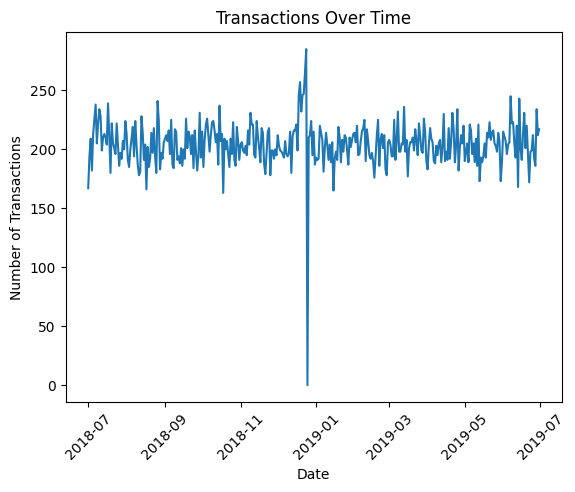

In [24]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(merged['DATE'], merged['num_transactions'])
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.title('Transactions Over Time')
plt.show()

In [25]:
missing_date = merged[merged['num_transactions'] == 0]
print(missing_date)

          DATE  num_transactions
177 2018-12-25               0.0


### We can see that there is an increase in purchases in December and a break in late December. Let's zoom in on this.

In [26]:
december_data = merged[
    (merged['DATE'] >= '2018-12-01') &
    (merged['DATE'] <= '2018-12-31')
]

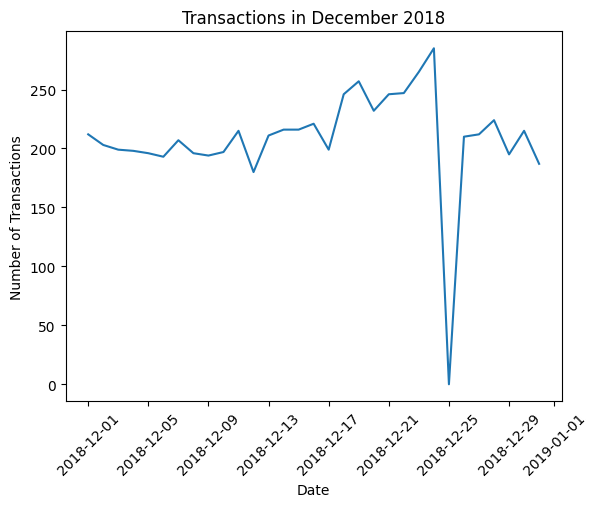

In [27]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(december_data['DATE'], december_data['num_transactions'])
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.title('Transactions in December 2018')
plt.show()

In [28]:
print(december_data.sort_values('num_transactions').head())

          DATE  num_transactions
177 2018-12-25               0.0
164 2018-12-12             180.0
183 2018-12-31             187.0
158 2018-12-06             193.0
161 2018-12-09             194.0


### We can see that the increase in sales occurs in the lead-up to Christmas and that there are zero sales on Christmas day itself. This is due to shops being closed on Christmas day.

### Now that we are satisfied that the data no longer has outliers, we can move on to creating other features such as brand of chips or pack size from PROD_NAME. We will start with pack size.

In [29]:
chips['PACK_SIZE'] = (
    chips['PROD_NAME']
    .str.extract(r'(\d+)\s*[gG]')
    .astype(float)
)

In [30]:
# Create a new column name Pack_size
chips['PROD_NAME'].str.contains(r'\d+\s*[gG]', na=False).sum()

np.int64(74570)

In [31]:
chips['PACK_SIZE'].value_counts().sort_index()

PACK_SIZE
110.0     9693
150.0     6376
160.0     2970
170.0    15413
175.0    29215
200.0     4473
330.0     3197
380.0     3233
Name: count, dtype: int64

In [32]:
print("Min pack size:", chips['PACK_SIZE'].min())
print("Max pack size:", chips['PACK_SIZE'].max())

Min pack size: 110.0
Max pack size: 380.0


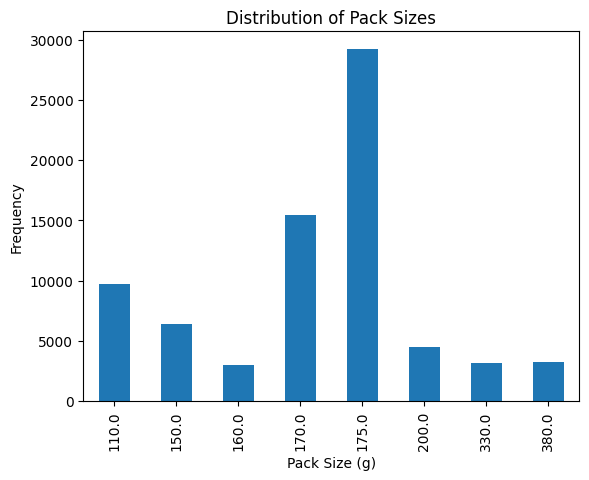

In [33]:
import matplotlib.pyplot as plt
plt.figure()
chips['PACK_SIZE'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Pack Size (g)')
plt.ylabel('Frequency')
plt.title('Distribution of Pack Sizes')
plt.show()

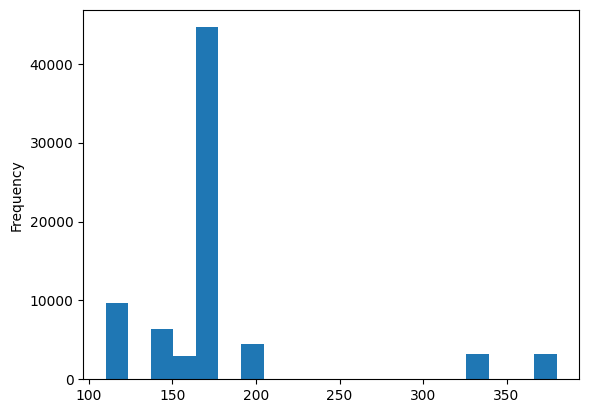

In [34]:
plt.figure()
chips['PACK_SIZE'].plot(kind='hist', bins=20)
plt.show()

### Now to create brands, we can use the first word in PROD_NAME to work out the brand name


In [35]:
BRAND_LOOKUP = [
    (r"\bRRD\b",              "Red Rock Deli"),
    (r"\bRed Rock Deli\b",    "Red Rock Deli"),
    (r"\bNCC\b",              "Natural Chip Co"),
    (r"\bNatural Chip\s*Co\b","Natural Chip Co"),
    (r"\bNatural Chip\b",     "Natural Chip Co"),
    (r"\bGrnWves\b",          "Grain Waves"),
    (r"\bGrain Waves\b",      "Grain Waves"),
    (r"\bInfzns\b",           "Infuzions"),
    (r"\bInfuzions\b",        "Infuzions"),
    (r"\bSnbts\b",            "Sunbites"),
    (r"\bSunbites\b",         "Sunbites"),
    (r"\bOld El Paso\b",      "Old El Paso"),
    (r"\bSmith(?:s)?\b",      "Smiths"),
    (r"\bDorito(?:s)?\b",     "Doritos"),
    (r"\bKettle\b",           "Kettle"),
    (r"\bPringles\b",         "Pringles"),
    (r"\bTwisties\b",         "Twisties"),
    (r"\bThins\b",            "Thins"),
    (r"\bTostitos\b",         "Tostitos"),
    (r"\bTyrrells\b",         "Tyrrells"),
    (r"\bCobs\b",             "Cobs"),
    (r"\bCheetos\b",          "Cheetos"),
    (r"\bCheezels\b",         "Cheezels"),
    (r"\bCCs\b",              "CCs"),
    (r"\bWoolworths\b",       "Woolworths"),
    (r"\bWW\b",               "Woolworths"),
    (r"\bBurger Rings\b",     "Burger Rings"),
    (r"\bFrench Fries\b",     "French Fries"),
]

In [36]:

COMPILED_LOOKUP = [(re.compile(pat, re.IGNORECASE), brand)
                   for pat, brand in BRAND_LOOKUP]

In [37]:
def extract_brand(prod_name: str) -> str:
    cleaned = " ".join(prod_name.split())
    for pattern, brand in COMPILED_LOOKUP:
        if pattern.search(cleaned):
            return brand
    weight_re = re.compile(r"^\d+[gG]$")
    for token in cleaned.split():
        if token[0].isupper() and not weight_re.match(token):
            return token
    return cleaned.split()[0]

In [38]:
chips.loc[:, "BRAND"] = chips["PROD_NAME"].apply(extract_brand)

In [39]:
print(chips[["PROD_NAME", "BRAND"]].drop_duplicates().sort_values("BRAND"))
print(f"\nChips rows  : {len(chips)}")
print(f"Unique brands: {chips['BRAND'].nunique()}")
print(chips["BRAND"].value_counts())

                                    PROD_NAME            BRAND
100    Cobs Popd Sour Crm  &Chives Chips 110g             Cobs
81             Cobs Popd Sea Salt  Chips 110g             Cobs
73   Cobs Popd Swt/Chlli &Sr/Cream Chips 110g             Cobs
103     Doritos Corn Chips  Nacho Cheese 170g          Doritos
88    Doritos Corn Chips  Cheese Supreme 170g          Doritos
8     Doritos Corn Chip Mexican Jalapeno 150g          Doritos
18    Doritos Corn Chip Southern Chicken 150g          Doritos
68          Doritos Corn Chips  Original 170g          Doritos
86             French Fries Potato Chips 175g     French Fries
0      Natural Chip        Compny SeaSalt175g  Natural Chip Co
75    Natural Chip Co     Tmato Hrb&Spce 175g  Natural Chip Co
487    Natural ChipCo Sea  Salt & Vinegr 175g  Natural Chip Co
40     Natural ChipCo      Hony Soy Chckn175g  Natural Chip Co
137   Smiths Crinkle Cut  Chips Barbecue 170g           Smiths
127    Smiths Chip Thinly  CutSalt/Vinegr175g          

### In this version of data I didn't find any chips brand named RED ROCK DELI. May be this brand has different products but not chips.

# Examining customer data.Now that we are happy with the transaction dataset, let's have a look at the customer dataset.

#### Examining customer data

In [40]:
customerData.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [41]:
customerData.info()

<class 'pandas.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   LYLTY_CARD_NBR    72637 non-null  int64
 1   LIFESTAGE         72637 non-null  str  
 2   PREMIUM_CUSTOMER  72637 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.7 MB


In [42]:
chips.info()

<class 'pandas.DataFrame'>
Index: 74570 entries, 0 to 264834
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype        
---  ------          --------------  -----        
 0   DATE            74570 non-null  datetime64[s]
 1   STORE_NBR       74570 non-null  int64        
 2   LYLTY_CARD_NBR  74570 non-null  int64        
 3   TXN_ID          74570 non-null  int64        
 4   PROD_NBR        74570 non-null  int64        
 5   PROD_NAME       74570 non-null  str          
 6   PROD_QTY        74570 non-null  int64        
 7   TOT_SALES       74570 non-null  float64      
 8   PACK_SIZE       74570 non-null  float64      
 9   BRAND           74570 non-null  str          
dtypes: datetime64[s](1), float64(2), int64(5), str(2)
memory usage: 6.3 MB


## let's merge customer and chips transaction data

In [43]:
merged = chips.merge(customerData, on="LYLTY_CARD_NBR", how="left")

In [45]:
merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 74570 entries, 0 to 74569
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype        
---  ------            --------------  -----        
 0   DATE              74570 non-null  datetime64[s]
 1   STORE_NBR         74570 non-null  int64        
 2   LYLTY_CARD_NBR    74570 non-null  int64        
 3   TXN_ID            74570 non-null  int64        
 4   PROD_NBR          74570 non-null  int64        
 5   PROD_NAME         74570 non-null  str          
 6   PROD_QTY          74570 non-null  int64        
 7   TOT_SALES         74570 non-null  float64      
 8   PACK_SIZE         74570 non-null  float64      
 9   BRAND             74570 non-null  str          
 10  LIFESTAGE         74570 non-null  str          
 11  PREMIUM_CUSTOMER  74570 non-null  str          
dtypes: datetime64[s](1), float64(2), int64(5), str(4)
memory usage: 6.8 MB


### Let's save and export this clean and modified data set for furture exploration


In [46]:
merged.to_csv('clean_data')